In [1]:
import os
import chromadb
import warnings
warnings.filterwarnings("ignore")
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import TavilySearchResults, DuckDuckGoSearchRun
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, MessagesState, START
from langchain_core.tools import tool
from typing import Literal
from langchain_community.document_loaders import WebBaseLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import Graph
from langchain.vectorstores import Chroma
from pydantic import BaseModel, Field

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
load_dotenv()

True

In [25]:
embeddings = OpenAIEmbeddings()
parser = StrOutputParser()
llm = ChatOpenAI(model="gpt-4o-mini")

In [26]:
from IPython.display import Image, display
def displayGraph(app):
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        # This requires some extra dependencies and is optional
        print(e)

In [27]:
search = DuckDuckGoSearchRun()
def get_search_result(query: str):
    """This is a tool for searching about anything. For eg: Getting the details of the city, research about a company, etc"""
    return search.invoke(query)

In [9]:
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

In [10]:
import yfinance as yf

def get_stock_price(ticker: str) -> float:
    """Gets a stock price from Yahoo Finance.

    Args:
        ticker: ticker str
    """
    # """This is a tool for getting the price of a stock when passed a ticker symbol"""
    stock = yf.Ticker(ticker)
    return stock.info['previousClose']

In [28]:
tools = [get_search_result, add, get_stock_price]
llm_with_tool=llm.bind_tools(tools)

In [ ]:
def call_model(state: MessagesState):
    print("-----call_model-----")
    print(state)
    print("-----call_model-----")
    messages = state['messages']
    sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs.")
    response = llm_with_tool.invoke([sys_msg]+messages) #Use llm_with_tool instead of llm
    return {"messages": [response]}

In [30]:
def router(state: MessagesState):
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [31]:
workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", ToolNode(tools))

workflow.set_entry_point("agent")

workflow.add_conditional_edges(
    "agent",
    router,
    {
        "tools": "tools",
        END: END
    },
)

workflow.add_edge("tools", "agent")
app = workflow.compile()

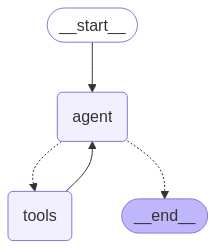

In [32]:
displayGraph(app)

In [33]:
answer = app.invoke(input={"messages": ["Tell me about the Apple stock, and add 100 to the stock price. Return the final stock price after performing the operation."]})

-----call_model-----
{'messages': [HumanMessage(content='Tell me about the Apple stock, and add 100 to the stock price. Return the final stock price after performing the operation.', additional_kwargs={}, response_metadata={}, id='a156a52d-9999-48ac-8ff7-daf8e3393c8f')]}
-----call_model-----
-----call_model-----
{'messages': [HumanMessage(content='Tell me about the Apple stock, and add 100 to the stock price. Return the final stock price after performing the operation.', additional_kwargs={}, response_metadata={}, id='a156a52d-9999-48ac-8ff7-daf8e3393c8f'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_BieVvC1TgSsmJN3FSBs16tdi', 'function': {'arguments': '{"ticker":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 169, 'total_tokens': 186, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_predict

In [34]:
answer

{'messages': [HumanMessage(content='Tell me about the Apple stock, and add 100 to the stock price. Return the final stock price after performing the operation.', additional_kwargs={}, response_metadata={}, id='a156a52d-9999-48ac-8ff7-daf8e3393c8f'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_BieVvC1TgSsmJN3FSBs16tdi', 'function': {'arguments': '{"ticker":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 169, 'total_tokens': 186, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BNna0qaMyjj0TFqzOofptWb8SBeRX', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-373a12a0-8ea6-4d60-a71c-f421623e6b2d-0', to

In [35]:
answer['messages']

[HumanMessage(content='Tell me about the Apple stock, and add 100 to the stock price. Return the final stock price after performing the operation.', additional_kwargs={}, response_metadata={}, id='a156a52d-9999-48ac-8ff7-daf8e3393c8f'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_BieVvC1TgSsmJN3FSBs16tdi', 'function': {'arguments': '{"ticker":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 169, 'total_tokens': 186, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BNna0qaMyjj0TFqzOofptWb8SBeRX', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-373a12a0-8ea6-4d60-a71c-f421623e6b2d-0', tool_calls=[{'na

In [36]:
for m in answer['messages']:
    m.pretty_print()

================================ Human Message =================================

Tell me about the Apple stock, and add 100 to the stock price. Return the final stock price after performing the operation.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (call_BieVvC1TgSsmJN3FSBs16tdi)
 Call ID: call_BieVvC1TgSsmJN3FSBs16tdi
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

194.27
================================== Ai Message ==================================
Tool Calls:
  add (call_mpa9ZF7zcKa2cH25tZtRGI7H)
 Call ID: call_mpa9ZF7zcKa2cH25tZtRGI7H
  Args:
    a: 194
    b: 100
================================= Tool Message =================================
Name: add

294
================================== Ai Message ==================================

The current stock price of Apple (AAPL) is $194.27. After adding 100, the final stock price is $

In [39]:
answer = app.invoke(input={"messages": ["Who's the richest person on the planet? Find the company owned by the richest person. Moreover, find the company's stock price and then add $100 to it's price."]})

-----call_model-----
{'messages': [HumanMessage(content="Who's the richest person on the planet? Find the company owned by the richest person. Moreover, find the company's stock price and then add $100 to it's price.", additional_kwargs={}, response_metadata={}, id='81e9dc23-4ceb-48f6-9f5a-a5245216675e')]}
-----call_model-----
-----call_model-----
{'messages': [HumanMessage(content="Who's the richest person on the planet? Find the company owned by the richest person. Moreover, find the company's stock price and then add $100 to it's price.", additional_kwargs={}, response_metadata={}, id='81e9dc23-4ceb-48f6-9f5a-a5245216675e'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_5my9PlCsEVjGM8ZPRRqgm1xF', 'function': {'arguments': '{"query":"richest person on the planet October 2023"}', 'name': 'get_search_result'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 176, 'total_tokens': 201, 'completion_

In [42]:
answer['messages']

[HumanMessage(content="Who's the richest person on the planet? Find the company owned by the richest person. Moreover, find the company's stock price and then add $100 to it's price.", additional_kwargs={}, response_metadata={}, id='81e9dc23-4ceb-48f6-9f5a-a5245216675e'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_5my9PlCsEVjGM8ZPRRqgm1xF', 'function': {'arguments': '{"query":"richest person on the planet October 2023"}', 'name': 'get_search_result'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 176, 'total_tokens': 201, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BNnbp6ItvRsBsC3KZsH5inASDMZEb', 'finish_reason': 'tool_calls', 'logprobs'

In [40]:
for m in answer['messages']:
    m.pretty_print()

================================ Human Message =================================

Who's the richest person on the planet? Find the company owned by the richest person. Moreover, find the company's stock price and then add $100 to it's price.
================================== Ai Message ==================================
Tool Calls:
  get_search_result (call_5my9PlCsEVjGM8ZPRRqgm1xF)
 Call ID: call_5my9PlCsEVjGM8ZPRRqgm1xF
  Args:
    query: richest person on the planet October 2023
================================= Tool Message =================================
Name: get_search_result

The Bloomberg Billionaires Index is a daily ranking of the world's richest people. Details about the calculations are provided in the net worth analysis on each billionaire's profile page. Who Is the World's Richest Man in 2025? As of April 1, 2025, the world's richest man is Elon Musk, the CEO of Tesla and SpaceX. He has a net worth of $316 billion. As of October 1, 2023, the richest man in the world i